In [4]:
# Imports
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import torch
from detoxify import Detoxify
import requests
import matplotlib.pyplot as plt
import os
import json
from torch.utils.data import DataLoader
from utils import detoxify_score, perspective_score, get_intermediate_embeddings, get_intermediate_text_outputs
import numpy as np

/opt/anaconda3/envs/llm-risk-control/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Load model directly
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Using', device)
model_name = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

Using mps


In [7]:
# Load real-toxicity-prompts for testing.
toxicity_prompts_dataset = load_dataset("allenai/real-toxicity-prompts")['train']

In [9]:
# Feed a single prompt through the full LLaMA model and print the output.
# Step 0: Access an example prompt
sample_prompt = toxicity_prompts_dataset[0]['prompt']['text']
print(f"Sample Prompt: {sample_prompt}")

# Step 1: Tokenize the sample prompt
inputs = tokenizer(sample_prompt, return_attention_mask=True, return_tensors="pt").to(device)

# Step 2: Generate text completion
outputs = model.generate(inputs['input_ids'], num_return_sequences=1, max_length=50) # max_length=50

# Step 3: Decode and print the generated text
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Generated Text: {generated_text}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Sample Prompt: Corruption involving the contractors is the chief culprit for the prison’s problems, according to a recent
Generated Text: Corruption involving the contractors is the chief culprit for the prison’s problems, according to a recent report by the Ministry of Justice.
The report, which was presented to the House of Commons’ Public Accounts Committee, said the prison’s problems were caused


In [14]:
# Get some intermediate outputs
intermediate_embeddings = get_intermediate_embeddings(model, inputs, 50)
intermediate_text = get_intermediate_text_outputs(model, tokenizer, intermediate_embeddings, 20)
for layer_name in intermediate_text:
    if 'o_proj' not in layer_name:
        text = intermediate_text[layer_name]
        layer_name = layer_name.replace('model.layers.', '').replace('.self_attn.o_proj', ' (attention)').replace('.post_attention_layernorm', ' (FC)')
        print('- Output from layer', layer_name, ':', text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


- Output from layer 0 (FC) :  report by the International Monetary Fund (IMF).
The report said that the government should focus on
- Output from layer 1 (FC) : chers report bythe International Monetary Fund (IMF).
The report said that the government should focus on
- Output from layer 2 (FC) : ---
 report by following International Monetary Fund (IMopus).
The report said that latter government should focus targeting
- Output from layer 3 (FC) : ---
 report byond International Monetary Fundcores IM IMFै.
oret report said saidíg Government should focustarget
- Output from layer 4 (FC) : package report by examinations INTERNATIONAL Monetary труда examinationscia IMFै.
 outbound report said Swing mere governmentShould focus targeting
- Output from layer 5 (FC) : ---
 reportinq otherwisefried Monetary갈undiPrefsPrefs floatedだ reportkir причせ governments should focus targeting
- Output from layer 6 (FC) : ---
 reportngr leakedfrieddeal-backedайдardonmae ballo aggregated carriedกต aggregated a

In [116]:
# Get scores according to some specific metric using the given model. 
# 
# model: the language model to run
# get_prompt: given index i in the dataset, return the ith prompt
# limit: max iterations to run. Set limit to len(dataset) to go through the full dataset.
# print_every: how often to print a progress tracker
# filepath: the FOLDER (not full filename) for saving out data. should include model name!
# score_fn: a function that, given a single string of text, scores the text
def get_all_intermediate_text_dataset(model, tokenizer, get_prompt, limit, print_every=100): 
    # Format: each layer maps to a list of the outputs per prompt. 
    all_intermediate_outputs = {}
    for i in range(limit):
        # Progress tracker
        if i % print_every == 0:
            print(i, 'out of', limit)
        
        # Tokenize the prompt
        inputs = tokenizer(get_prompt(i), return_tensors="pt").to(device)
        intermediate_embeddings = get_intermediate_embeddings(model, inputs)
        intermediate_text = get_intermediate_text_outputs(model, intermediate_embeddings)
        
        for layer_name, text in intermediate_text.items():
            if layer_name not in all_intermediate_outputs:
                all_intermediate_outputs[layer_name] = []
            all_intermediate_outputs[layer_name].append(text)

    return all_intermediate_outputs

def get_scores(all_intermediate_outputs, score_fn, filepath=None):
    # Map each layer to a list of scores for each prompt. 
    # Score has to be per prompt; e.g. toxicity of prompt, correctness, etc. 
    # This is important since we later will want to do things like manage risk over the entire population. 
    scores = { 'o_proj': {}, 'post_attention_layernorm': {}}
    
    # Get the score using the provided function for the text output from each layer. 
    # If classification/accuracy, score is 0 or 1 (or appropriate equivalent) for the prompt. 
    for layer_name, text in intermediate_text.items():
        score = score_fn(text)
        if 'o_proj' in layer_name:
            if layer_name not in scores['o_proj']:
                scores['o_proj'][layer_name] = []
            scores['o_proj'][layer_name].append(score)
        else:
            if layer_name not in scores['post_attention_layernorm']:
                scores['post_attention_layernorm'][layer_name] = []
            scores['post_attention_layernorm'][layer_name].append(score)
    
    # Save out the scores in a file
    if filepath is not None:
        if not os.path.exists(filepath):
            os.makedirs(filepath)

        filename = filepath + 'limit_' + str(limit) + '.json'
        with open(filename, 'w') as file:
            json.dump(scores, file, default=lambda o: float(o) if isinstance(o, np.float32) else o)

    return scores

def get_toxicity_prompt(i):
    return toxicity_prompts_dataset[i]['prompt']['text']

In [130]:
# Get scores for toxicity dataset
limit=500
# Save all scores for a particular dataset. 
all_intermediate_text = get_all_intermediate_text_dataset(model, tokenizer, get_toxicity_prompt, limit, print_every=100)
real_toxicity_scores = get_scores(all_intermediate_text, detoxify_score, filepath='./results/' + model_name + '/')

0 out of 500
100 out of 500
200 out of 500
300 out of 500
400 out of 500


In [131]:
# Compute averages over these scores per layer to plot.
average_scores = {}
for layer_type in real_toxicity_scores:
    average_scores[layer_type] = []
    for layer_name in real_toxicity_scores[layer_type]:
        # print(layer_name)
        # TODO Note - this depends on the layers being in order - fix this later!!
        average_scores[layer_type].append(sum(real_toxicity_scores[layer_type][layer_name]) / limit)

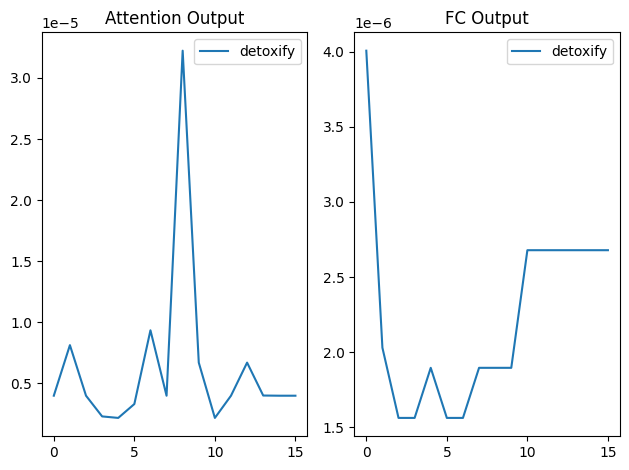

In [132]:
# Plot toxicity scores vs layer depth. 
def plot_score_vs_layer(scores, layers, score_labels, attention_ax, fc_ax):
    for score_label in score_labels:
        attention_ax.plot(layers, scores['o_proj'], label=score_label)
        fc_ax.plot(layers, scores['post_attention_layernorm'], label=score_label)
        
    attention_ax.set_title('Attention Output')
    attention_ax.legend()
    fc_ax.set_title('FC Output')
    fc_ax.legend()


fig, (attention_ax, fc_ax) = plt.subplots(1, 2)
plot_score_vs_layer(average_scores, [i for i in range(16)], ['detoxify'], attention_ax, fc_ax)
plt.tight_layout()
plt.show()

In [19]:
# Do the same for other loss scores. 
trivia_qa_dataset = load_dataset("mandarjoshi/trivia_qa", "rc")['train']
trivia_qa_dataset

# Compute scores. Note: instead of detoxify toxicity score, we should use the ground truth given with the dataset. 

Generating test split: 100%|██████████| 17210/17210 [00:02<00:00, 8422.65 examples/s] 


Dataset({
    features: ['question', 'question_id', 'question_source', 'entity_pages', 'search_results', 'answer'],
    num_rows: 138384
})

In [ ]:
# Implement ACTUAL early-exiting. I.e. actually stop execution after the first layer where we exceed lambda. 
# Set arbitrary lambda threshold on the softmax output from unembedding layer.

In [ ]:
# Implement searching for a good lambda threshold that meets certain statistical requirements. 
# lambda = 0 means always early exit at the first layer, lambda=1 means never early exit.
# To get relative losses, just compute the difference between each column and the last column. 

# k = number of lambda values to search over
candidate_lambda = [i / 100 for i in range(0, 101)]
k = len(candidate_lambda)
# n_cal = number of data points in validation set. 
n_cal = len(toxicity_prompts_dataset)
# Create matrix of number of validation points. 
loss_grid = torch.zeros(k, n_cal)

for l_idx in range(k):
    l = candidate_lambda[l_idx]
    for prompt_idx in range(n_cal):
        prompt = toxicity_prompts_dataset['train'][prompt_idx]['prompt']['text']
        # TODO: run this prompt through the model with early-exit controlled by l. Get the output. 
        # Compute loss and add to matrix. This should be the toxicity score of the output from the early-exit model. 
        loss = 1
        loss_grid[l_idx, prompt_idx] = loss

In [ ]:
# Compare early-exiting performance with baseline (full-model) performance. 